In [1]:
pip install ~/fwiVis/utility_functions/

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=19526 sha256=663f8e80721a95cc5ec41b1e6fa15cfd45d13d00bd62916fc776499a57a93484
  Stored in directory: /tmp/pip-ephem-wheel-cache-x_rsjpm8/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
#import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
import shapely
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date

import seaborn as sn
sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

In [3]:
def get_centroid(df):
    df_tmp = df[~df.geometry.isnull()]
    df_tmp["farea_unitless"] = df_tmp.geometry.area
    max_u = df_tmp.farea_unitless.max()
    lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
    lon = df_tmp[df_tmp.farea_unitless == max_u].centroid.x
    #print(lat.iloc[0])
    df["lat_centroid"] = lat.iloc[0]
    df["lon_centroid"] = lon.iloc[0]
    return(df)



def diff_fix(df, col = "farea"):
    #df = df2
    fid = "fire"
    df = df.sort_values(by = "t")
    df[col+ "_diff"] = df[col].diff()

    df[col+ "_diff_round"] = df[col+ "_diff"].round(4) ## Correcting for negatives introduced by numarical instabilities/ rounding differences and create very small negative numbers
    
    ### Go through and finding times when fire area is negative, checking for change in area from previous, and using that number as "merge ignition". 
    df["geometry_difference_manual"] = None
    df["area_from_geometry_difference_manual"] = None
    fireID_t_pairs = df.loc[(df.farea_diff_round < 0), ["t"]].reset_index(drop = True)
    for i in range(0, len(fireID_t_pairs)):
        #fid = fireID_t_pairs.iloc[i].iloc[0]
        t = str(fireID_t_pairs.iloc[i].iloc[0])
        t_obj = datetime.strptime(t, "%Y-%m-%d %H:%M:%S")
        t_previous = t_obj - timedelta(hours=12)
        t_previous = t_previous.strftime("%Y-%m-%d %H:%M:%S")
        row_mask_t =  (df.t == t) # (df.fireID == fid) &
        row_mask_t_prev =  (df.t == t_previous) # (df.fireID == fid) &
        if( len(df.loc[row_mask_t_prev, "geometry"]) == 0 ):
            print(f"Warning: {fid} does not have t {t_previous}. Trying timestep 12 hours earlier.")
            t_previous = t_obj - timedelta(hours=24)
            t_previous = t_previous.strftime("%Y-%m-%d %H:%M:%S")
            row_mask_t_prev = (df.t == t_previous) # (df.fireID == fid) & 
            #print(f"Warning: {fid} does not have t {t_previous}. Trying timestep 12 hours earlier.")
            #print(df[row_mask_t_prev])
            #print(i)
            if(len(df.loc[row_mask_t_prev, "geometry"]) == 0 ):
                print(f"Warning: {fid} STILL does not have t {t_previous}. Attempting to extract next best timestep.")
                t_previous = df.loc[ (df.t < t)].t.max() # (df.fireID == fid) &
                row_mask_t_prev = (df.t == t_previous) # (df.fireID == fid) & 
                print(f"Warning: previous timesetp being set to {t_previous}.")
        #print()
        #print(fid)
        df.loc[row_mask_t, ["geometry_difference_manual"]] = df.loc[row_mask_t, "geometry"].drop_duplicates().iloc[0].symmetric_difference(df.loc[row_mask_t_prev, "geometry"].drop_duplicates().iloc[0])
        df.loc[row_mask_t, "area_from_geometry_difference_manual"] =  round(df.loc[row_mask_t, ["geometry_difference_manual"]].drop_duplicates().iloc[0].iloc[0].area, 4) ## Round to correct weird numerical stuff
    
    conditional = df[col+ "_diff"].isna()
    
    # Missing ignition area, but actually very hard to get from "corrected" FEDS right now. Was getting a lot of "double counted" fire area when a fire would die down then spring up again. 
    # I am now defining fire area spread as seperate from ignition area, because it makes almost no difference for the small cases, but a huge difference for the large cases where we need to start defining "spread". When a Fire wakes back up is that spread? I think it isn't. 
    
    if(len(df.loc[conditional, col+ "_diff"]) == 1):
        #return(df)
        df.loc[conditional, col+ "_diff"] = df.loc[conditional, col] ## Setting the first value column that the differenceing is happening in. In fire area, represents the ingition area
        #print(df.loc[conditional, col])
       # print( df.loc[conditional, col+ "_diff"])
    else:
        print(f"ERROR: More that one nan value in diff! Does not represent first value of {col}!" )
        
    ##
        
    #df.loc[df[col+ "_diff_round"] < 0, [col+ "_diff"]] = df.loc[df[col+ "_diff_round"] < 0 , [col]] ## If there is a negative difference, means that there was a new fire merged in that also has it's ignition area
    #df.loc[df[col+ "_diff_round"] < 0, [col+ "_diff"]] = 0 # I thought the comment above, but actually, mostly I was seeing fires that "Should" have been the same, aka burnt so long that FEDS assumed they were out and started another fire with a new ID. Adding an "ignition area" just duplicated the area of the long fires 
    df.loc[df[col+ "_diff_round"] < 0, [col+ "_diff"]] = df.loc[df[col+ "_diff_round"] < 0 , ["area_from_geometry_difference_manual"]]
    #     print("Error: DF not mutating.")
    return(df)
    
# def corrected_farea_diff(df, var = "farea"):
#     #sub_df = df[]
#     df = df.drop_duplicates()
#     df[f"{var}_diff"] = df[var].diff()
#     min_t = df.t.min()
#     #print()
#     #print(df.loc[df.t == min_t, ["fireID", "t", "farea", "farea_diff"]])
    
#     if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
#         df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
#     else:
#         print("Error! First value not NaN")
#         df = None
#     return(df)

# def average_var_from_multiple_fires(remerged):

#     FWI_merge = remerged.groupby(["fireID", "t"]).FWI.mean().reset_index()
#     FWI_merge = FWI_merge.dropna()
#     FWI_merge


#     cp_remerge = remerged

#     cp_remerge = remerged[['fireID', 't', 'geometry', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
#            'flinelen', 'duration', 'pixden', 'meanFRP']]

#     cp_remerge = cp_remerge.merge(FWI_merge, on = ["fireID", "t"], how = "inner")
#     cp_remerge = cp_remerge.drop_duplicates()
#     return(cp_remerge)


# ### Just for processing the timeseries at the end

# def chop_fires_at_end(df):
#     if(len(df[df.n_newpixels > 0]) > 0 ): 
#         final_t = df[df.n_newpixels > 0].t.max()
#         df = df[df.t <= final_t]
#     else:
#         df = df[df.t == df.t.min()] ## If the fire had it's only growth increment during the 12 hour period we aren't looking at (ie spread in the AM overpass)
#     return(df)

In [4]:
### Now with feds perimeters

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/20_days_fire_stats_only_718270-99999_minT20230301_maxT20230830_BOREAL_NRT_3571_DPSstation20231120.csv" ## looking for lightning 20 days before start

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv" ### The weirder fires. 

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_06172024.csv" # Fires with "fixed' lf bug. 

# path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_plus_area_fix_09042024.csv" # Fires with merge fix + chaining fires fix + fires alseep fix
# fires = fv.prep_fire_files(path, crs = "4326")

fires = gpd.read_file("~/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb")

fires = fires.to_crs(4326)

#fires = fv.remerge_largefire(fires) ### CAUSES ISSUES WITH AREA DIFFERENCING. 

ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]

ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

ciffc["geometry_point"] = ciffc.geometry


### Just for timeseries at the end
path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
#path = os.path.abspath("data/Quebec_v3_full_data_perimetersMAX_fwi_with_ISI_and_BUIful_timeseries_202534.csv")
fire3 = fv.prep_fire_files(path) 
fire3 = fire3.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop = True)
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3.drop_duplicates()
fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()

/tmp/ipykernel_4644/1448419386.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop = True)


In [5]:
print(len(fires.fireID.unique()))

fires = fires[~fires.geometry.isna()]

fires = fires.sort_values(by = ["fireID", "t"])


204


In [6]:
fires.t = pd.to_datetime(fires.t, format='ISO8601')

#fires.better_format_date.astype("datetime64[ns]")
fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d %p")
fires = fires[fires.pretty_date_format.str.contains("PM")] ## Make  only PM to PM comparisons

fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d")

#fires["farea_diff"] = fires.groupby("fireID").farea.diff()n # Old diff function 

fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
fireIDs = fires.fireID.unique()


fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ### this got rid of 3 fireIDs. Why? no new pixels? 
post_chop_fireIDs = fires.fireID.unique()
new_list = list(set(fireIDs).difference(post_chop_fireIDs))

fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=True)


/tmp/ipykernel_4644/1229207234.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
/tmp/ipykernel_4644/1229207234.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ### this got rid of 3 fireIDs. Why? no new pixels?
/tmp/ipykernel_4644/3314272417.py:3: 

In [7]:
no_dupes = fires[["fireID", "pretty_date_format", "farea_diff", "lat_centroid", "t"]]  ## 201 fires, 3 less than 



no_dupes = no_dupes.dropna()
no_dupes = no_dupes.drop_duplicates(subset = ["fireID", "t"])
no_dupes["log_difference"] = np.log(no_dupes.farea_diff)

/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
# Get the mean centroid point per fireID

lats = no_dupes[['fireID', 'pretty_date_format', 'farea_diff', 'lat_centroid', 't',
       'log_difference']].groupby("fireID").lat_centroid.mean().reset_index()
lats

,fireID,lat_centroid
0,11.0,45.829841
1,15.0,46.483832
2,23.0,45.571959
3,36.0,45.741825
4,183.0,44.729042
...,...,...
199,3622.0,50.628108
200,3629.0,52.837987
201,3700.0,50.556413
202,3712.0,50.153088


In [9]:
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator

#no_dupes = no_dupes[['fireID', 'pretty_date_format', 'farea_diff', 'log_difference', 't']].merge(lats, on = ["fireID"])
no_dupes = no_dupes[['fireID','pretty_date_format', 'farea_diff', 'log_difference', 't']].reset_index().merge(lats, on = ["fireID"])

In [10]:

no_dupes["farea_diff_mod"] = no_dupes.farea_diff + 1 # Account for log. Minimum = 1. 
no_dupes.loc[(no_dupes.farea_diff_mod < 0), ["farea_diff_mod"]] = 1

print(no_dupes.columns)

#heat = no_dupes.pivot(index =["fireID", "lat_centroid"],  columns=["pretty_date_format"], values="farea_diff")
#heat = no_dupes.pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values="farea_diff")
heat = no_dupes.pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values="farea_diff_mod")

Index(['index', 'fireID', 'pretty_date_format', 'farea_diff', 'log_difference',
       't', 'lat_centroid', 'farea_diff_mod'],
      dtype='object')


In [11]:
heat = heat.sort_values(by = "lat_centroid", ascending= False)
heat.index = heat.index.astype("float64")

heat.index = heat.index.values.round(2)



In [12]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv')

In [13]:
fwis = FWI_data_south[["INITDATE", "0"]]
fwis = fwis.rename(columns={"0":"GEOS_5"})

fwin = FWI_data_north[["INITDATE", "0"]]
fwin = fwin.rename(columns={"0":"GEOS_5"})

Text(55.847222222222214, 0.5, 'FWI')

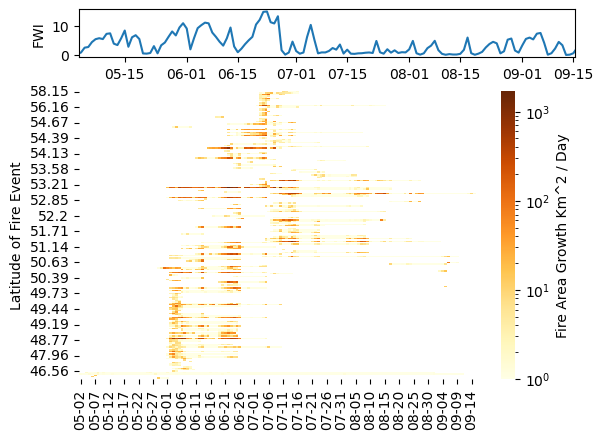

In [14]:
import matplotlib.dates as mdates

fig, (ax, ax2) = plt.subplots(2, gridspec_kw={'height_ratios': [1, 6]})
#fig.suptitle('Aligning x-axis using sharex')
ax2 = sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, fmt='.1f')#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
ax.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
ax.set_ylabel("FWI")
#plt.savefig(f"Regional_fire_growth_FWI_{datetime.today().strftime('%Y%m%d')}.png")

In [15]:
dates = no_dupes['t'].astype('datetime64[ns]')
dates = dates.drop_duplicates()
# print(len(dates.dt.strftime('%-m-%-d')))
# print(len(heat.columns))

In [16]:
### New Color bar

from matplotlib.colors import LinearSegmentedColormap

# Retrieve the original colormap
original_cmap = plt.get_cmap('YlOrBr')



def create_darker_colormap(base_cmap_name, darkness_factor):
    """
    Create a darker version of a given colormap.
    
    Parameters:
    - base_cmap_name: str, the name of the base colormap.
    - darkness_factor: float, a factor between 0 and 1 to darken the colormap.
                       1 means no change, 0 means completely dark.
    
    Returns:
    - LinearSegmentedColormap: a new colormap that is a darker version of the base colormap.
    """
    # Retrieve the original colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    
    # Create a list of colors from the colormap and darken them
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[:, :3] *= darkness_factor
    colors = np.clip(colors, 0, 1)  # Ensure values are within [0, 1]
    
    # Create the new colormap
    return LinearSegmentedColormap.from_list(f"{base_cmap_name}_darker", colors)

# Define the darkness factor (between 0 and 1)
darkness_factor = 0.85

# Create a custom colormap with the specified darkness factor
darker_cmap = create_darker_colormap('YlOrBr', darkness_factor)

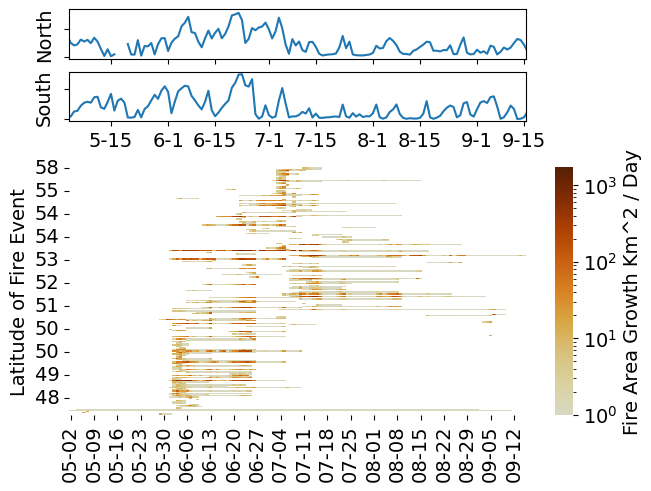

In [17]:
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.ticker import StrMethodFormatter
#from matplotlib.ticker import IndexFormatter
# fig, ax  = plt.subplots(2, 2, sharex='col', gridspec_kw={'width_ratios':[100,5]})
# ax[0,1].remove()  # remove unused upper right axes
# ax[0,0].plot(x+0.5,L_1,'-', marker='o',color='tab:orange')
# sn.heatmap(M_1, cmap=cmap, vmax=np.max(M_1), center=np.max(M_1)/2., square=False, ax=ax[1,0], cbar_ax=ax[1,1])

def quick_round(x, pos=None):
    x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)

def quick_round2(x, pos = None, obj = heat):
    x = int(x)
    #print(x)
    x = obj.index[x]
    #x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)


def quick_round3(x, pos = None, obj = heat):
    x = int(x)
    index = obj.index[x]
    #x = float(x)
    r = round(x, 0)
    r = int(r)
    return(r)
    
#plt.style.use('dark_background')
with mpl.rc_context({'font.size': 14}):
    fig, ([ax, ax2], [ax3, ax4], [ax5, ax6]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,1, 5]}, constrained_layout=True)
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
    ax.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
    ax.set_ylabel("North")
    ax.set_xticklabels("")
    ax.set_yticklabels("")


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
    ax3.set_xlim(no_dupes.t.astype("datetime64[ns]").min(), no_dupes.t.astype("datetime64[ns]").max())
    ax3.set_ylabel("South")
    ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(heat, cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))

    #ax5.yaxis.set_major_formatter(StrMethodFormatter('{x:,f}'))
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round))
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #fmtr = mpl.ticker.FuncFormatter(heat.index.round(0))
   
    ax2.remove()
    ax4.remove()

    #plt.gcf().subplots_adjust(bottom=0.15)
    #plt.tight_layout()
    #plt.show()
    #plt.savefig('darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)
    #plt.savefig('low_rez_darker_Regional_fire_growth_FWI.png', dpi = 100, transparent = False)
    #plt.savefig(f"/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [18]:
example = no_dupes[(no_dupes.lat_centroid <= 58.00) & (no_dupes.lat_centroid >= 54.86)].pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values="farea_diff")

In [19]:
def make_heat_map(path, piv_values, crs, start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00'):
    '''
    path (str): 
    piv_values (str):
    
    '''
    sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
    import fwiVis.fwiVis as fvs
    ## Read in 
    fires = fvs.prep_fire_files(path, crs = crs)
    #print(fires.crs)
    #fires = gpd.read_file(path)
    
    fires = fires.to_crs("EPSG:4326")
    fires = fires.sort_values(by = ["fireID", "t"])
    fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"
    #return(fires)
    fires = fires[~fires.geometry.isna()]
    fires = fires.drop_duplicates()

    ## subset by start and end time
    fires = fires[fires.t >= start_time]
    fires = fires[fires.t <= end_time]

    # ## Subset to the province of quebec
    # prov = fv.ca_prov()
    # prov = prov[prov.prov_name_en == "Quebec"]
    # prov = prov.to_crs('EPSG:3571')
    # fires = fires.to_crs('EPSG:3571')
    # fires = fires.sjoin(prov)
    # fires = fires.drop(['prov_name_fr', 'prov_name_en', 'index_right'], axis = 1)
    # fires = fires[~fire3.geometry.isna()]
    # fires = fires.to_crs("EPSG:4326")
    #print(f"Number of fireID in fires object {len(fires.fireID.unique())}")
    
    ## Merge with CIFFC
    fires.t = pd.to_datetime(fires.t, format='ISO8601')
    #return(fires)
    #fires = fires.sjoin(ciffc.to_crs("4326"))

    ## Merge with NBAC
    nbac_only = gpd.read_file(f"{os.path.abspath('contextual_data')}/NBAC/nbac_2023_20240530.shp")
    nbac_only = nbac_only[nbac_only.ADMIN_AREA == 'QC']
    nbac_only  = nbac_only [(nbac_only.ADJ_HA >= 400) |(nbac_only.POLY_HA >= 400)]
    nbac_only = nbac_only[(nbac_only.HS_SDATE <= "2023-09-15" ) |  (nbac_only.AG_SDATE <= "2023-09-15")]
    fires = fires.to_crs(nbac_only.crs)
    fires = fires.sjoin(nbac_only)
   #  fires = fires.drop(['YEAR', 'NFIREID', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
   # 'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
   # 'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
   # 'GID'], axis=1)
    fires = fires.drop(['YEAR', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
   'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
   'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
   'GID'], axis=1)
    fires = fires.to_crs("4326")
    
    #fires = average_var_from_multiple_fires(fires)
    fires.farea = fires.farea.astype("int64")

    #fires = fvs.formatting_read_in(path)

    ## Make the dataes into a nicer format
    fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d %p")
    fires = fires[fires.pretty_date_format.str.contains("PM")] ## Make  only noon to noon comparisons
    fires["pretty_date_format"] = fires.t.astype("datetime64[ns]").dt.strftime("%m-%d")
    print(f"Number of fireID in fires object {len(fires.fireID.unique())}")

    ### Cacluate number for plot
    #fires["farea_diff"] = fires.groupby("fireID").farea.diff()
    
    fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
    fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=True) ## get lat centroids for later use
    print(f"Number of fireID in fires object {len(fires.fireID.unique())}")

    ### Make a new datarame with no duplicates
    no_dupes = fires[["fireID", "pretty_date_format", "farea_diff", "lat_centroid", "t", "FWI"]]
    no_dupes = no_dupes.dropna()
    no_dupes = no_dupes.drop_duplicates(subset = ["fireID", "t"])
    no_dupes["log_difference"] = np.log(no_dupes.farea_diff)
    print(f"Number of fireID in no dupes object {len(no_dupes.fireID.unique())}")


    ### Find mean lat so that the lattitide axis is prettier
    lats = no_dupes[['fireID', 'pretty_date_format', 'farea_diff', 'lat_centroid', 't',
           'log_difference', "FWI"]].groupby("fireID").lat_centroid.mean().reset_index()
    no_dupes = no_dupes[['fireID','pretty_date_format', 'farea_diff', 'log_difference', 't', "FWI"]].reset_index().merge(lats, on = ["fireID"])

    ## Change values so they don't get set as NA on a log scale

    no_dupes["farea_diff_mod"] = no_dupes.farea_diff + 1 # Account for log. Minimum = 1. 
    no_dupes.loc[(no_dupes.farea_diff_mod < 0), ["farea_diff_mod"]] = 1

    print("modifying values to fit log color scale: 0 -> 1, nagative number -> 1")
    print(f"Number of fireID in no dupes object {len(no_dupes.fireID.unique())}")


    ### Put into pivot table
    
    heat = no_dupes.pivot(index =["lat_centroid"],  columns=['pretty_date_format'], values= piv_values)
    print(f"Number of fireID in heat object {len(heat)}")

    heat = heat.sort_values(by = "lat_centroid", ascending= False)
    heat.index = heat.index.astype("float64")

    heat.index = heat.index.values.round(2)
    print(f"Number of fireID in heat object {len(heat)}")

    return([heat, no_dupes])
    

In [20]:
#test_func = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_06172024.csv", "farea_diff_mod", crs = "3571")
path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire_test = fv.prep_fire_files(path)
test_func = make_heat_map(path, "farea_diff_mod", crs = "3571")

/tmp/ipykernel_4644/1061483567.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"


Number of fireID in fires object 160


/tmp/ipykernel_4644/1061483567.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop=True)
/tmp/ipykernel_4644/3314272417.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_tmp["farea_unitless"] = df_tmp.geometry.area
/tmp/ipykernel_4644/3314272417.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat = df_tmp[df_tmp.farea_unitless == max_u].centroid.y
/t

Number of fireID in fires object 160
Number of fireID in no dupes object 160
modifying values to fit log color scale: 0 -> 1, nagative number -> 1
Number of fireID in no dupes object 160
Number of fireID in heat object 160
Number of fireID in heat object 160


/tmp/ipykernel_4644/1061483567.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(get_centroid).reset_index(drop=True) ## get lat centroids for later use
/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:


zones = gpd.read_file(f"{os.path.abspath('contextual_data')}/supression_zones_quebec/Full_response_limit.shp")
zones= zones.set_crs(32198)

zones = zones.to_crs("4326")
zones['geometry'] = shapely.unary_union(zones.geometry)

def get_mid_line(bounds):
    mid_x = (bounds[0] + bounds[2])/2
    mid_y = (bounds[1] + bounds[3])/2
    mid_line = shapely.LineString([[bounds[0], mid_y], [mid_x, mid_y], [bounds[2], mid_y]])
    return(mid_line)

zones_avg_line = zones.copy()
zones_avg_line['geometry'] = get_mid_line(zones.geometry[0].bounds)


# def get_mid_line(bounds):
#     mid_x = (bounds[0] + bounds[2])/2
#     mid_y = (bounds[1] + bounds[3])/2
#     mid_line = shapely.LineString([[bounds[0], mid_y], [mid_x, mid_y], [bounds[2], mid_y]])
#     return(mid_line)


# zones_avg_line = zones.copy()
# zones_avg_line['geometry'] = get_mid_line(zones.geometry[0].bounds)

In [22]:
# print(test_func2[1].lat_centroid.min())
# print(test_func2[1].lat_centroid.max())

# print(test_func[1].lat_centroid.min())
# print(test_func[1].lat_centroid.max())

In [ ]:
# def current_tick_modify(ax, desired_value):
#     current_ticks = list(ax.get_yticks())
#     if desired_value not in current_ticks:
#         current_ticks.append(desired_value)
#         current_ticks.sort()
#     ax.set_yticks(current_ticks)

import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

# def current_tick_modify(ax, desired_value, max_ticks=4):
#     """Add a tick while maintaining good spacing"""
#     ylim = ax.get_ylim()
    
#     # Generate a reasonable number of ticks across the range
#     auto_ticks = np.linspace(ylim[0], ylim[1], max_ticks)
    
#     # Add your desired value
#     all_ticks = np.append(auto_ticks, desired_value)
    
#     # Remove duplicates and sort
#     all_ticks = np.unique(all_ticks)
    
#     # Only keep ticks within the y-limits
#     all_ticks = all_ticks[(all_ticks >= ylim[0]) & (all_ticks <= ylim[1])]
    
#     ax.yaxis.set_major_locator(ticker.FixedLocator(all_ticks))

# def current_tick_modify(ax, desired_value):
#     current_ticks = ax.get_yticks()
#     all_ticks = np.append(current_ticks, desired_value)
#     all_ticks = np.unique(all_ticks)
    
#     # Use FixedLocator to set the final ticks
#     ax.yaxis.set_major_locator(ticker.FixedLocator(all_ticks))




def interpolate_position(target_value, values, positions):
    """Get interpolated position for a target value"""
    # Create interpolation function (values to positions)
    # Note: values are in descending order, so we need to handle this
    interp_func = interp1d(values[::-1], positions[::-1], 
                          bounds_error=False, fill_value='extrapolate')
    
    return interp_func(target_value)

with mpl.rc_context({'font.size': 16}):
    fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
    #fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4], [ax6, ax7]) = plt.subplots(4,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1, 1]}, constrained_layout=True)
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5, color = "#12e8e2")
    ax.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax.set_ylabel("North") #  \n FWI"
    ax.set_xticklabels("")
    #ax.set_yticklabels("")
    ax.set_yticklabels("")
    ax.set_yticks([])

    ax1 = ax.twinx()
    ### LINES
    #current_tick_modify(ax1, 15)
    # ax1.axhline(y = 15, linestyle = "dashed", alpha = 0.5,  color = "gray")
    # ax1.axhline(y = 10, linestyle = "dashed", alpha = 0.5,  color = "gray")
    # ax1.axhline(y = 5, linestyle = "dashed", alpha = 0.5, color = "gray")
    ax1.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5, color = "#12e8e2")

    #ax1.yaxis.set_label_position('left')
    ax1.set_ylabel("FWI", loc = 'center')
    ax1.tick_params(axis='y', which='major', labelsize=14)
    #ax1.set_yticklabels("")
    #ax1.set_yticks([])

    ## Tick nonesense 
    #current_ticks = ax1.get_yticks()
    desired_ticks = [5, 15]
    # Combine and remove duplicates
    #all_ticks = list(current_ticks) + desired_ticks
    #all_ticks = sorted(list(set(all_ticks)))
    all_ticks = sorted(list(set(desired_ticks)))
    # Filter to keep only ticks within a reasonable range
    y_min, y_max = ax1.get_ylim()
    filtered_ticks = [tick for tick in all_ticks if y_min <= tick <= y_max]
    ax1.set_yticks(filtered_ticks)


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5, color = "#d85beb")
    ax3.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax3.set_ylabel("South")
    #ax3.set_yticklabels("")
    ax3.set_yticklabels("")
    ax3.set_yticks([])

    ax31 = ax3.twinx()
    ax31.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5, color = "#d85beb")
    ax31.set_ylabel("FWI", loc = 'center')
    ### LINES
    # ax31.axhline(y = 15, linestyle = "dashed", alpha = 0.5,  color = "gray")
    # ax31.axhline(y = 10, linestyle = "dashed", alpha = 0.5,  color = "gray")
    # ax31.axhline(y = 5, linestyle = "dashed", alpha = 0.5, color = "gray")
    ax31.tick_params(axis='y', which='major', labelsize=14)
    y_min, y_max = ax31.get_ylim()
    filtered_ticks = [tick for tick in all_ticks if y_min <= tick <= y_max]
    ax31.set_yticks(filtered_ticks)



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    average_suppressionBoundary = (zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2
    print(f"Average supression boundary is {average_suppressionBoundary} ")
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2)) ### Causes anindexing error but "Should" work

    ## Rounding Labs and setting where midline is proportinally to where labels are
    labs = ax5.get_yticklabels()
    foo = zones_avg_line.geometry.iloc[0].coords.xy
    target_value = foo[1][1] #zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2
    interpolated_pos = interpolate_position(
    target_value, 
    [float(obj.get_text()) for obj in labs],
    [obj.get_position()[1] for obj in labs]
    )
    
    ax5.axhline(y = interpolated_pos, color = "#86fd45", linestyle = "dotted", linewidth=3)

    labs_fix = []
    for l in labs:
        txt = quick_round(l.get_text())
        labs_fix.append(txt)
    ax5.set_yticklabels(labs_fix)
    
    #ax5.axhline(y = (zones.geometry[0].bounds[1]+ zones.geometry[0].bounds[3])/2, color = "#777777", linestyle = "dotted")
    #print((zones.geometry[0].bounds[1] + zones.geometry[0].bounds[3])/2)
    ax5.axes.get_xaxis().set_visible(False)
    
    
    #zones_avg_line.plot(ax= ax5, color = "#86fd45", linestyles='dotted', linewidths = 2)
    
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax6.plot()
    ax2.remove()
    ax4.remove()
    #ax7.remove()
    #plt.show()
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2)) ### Causes anindexing error but "Should" work
    plt.savefig(f"some_figs/low_rez_darker_Regional_fire_growth_FWI_with_line_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [24]:
remerged = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)

In [ ]:
#get_fwi = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_06172024.csv", "FWI")
#get_fwi = make_heat_map("/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_plus_area_fix_09042024.csv", "FWI", crs =  4326)
get_fwi = make_heat_map(os.path.abspath(f'data/Quebec_v3_full_data_perimeters20241112.csv'), "FWI", crs =  3571)

/tmp/ipykernel_4644/1061483567.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(fv.chop_fires_at_end).reset_index(drop=True) ## Find where fires "end"


In [ ]:
fig2, (ax2) = plt.subplots(1)
#fig.suptitle('Aligning x-axis using sharex')
ax2 = sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, fmt='.1f')#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")
#ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))


#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
#ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#ax.set_xlim(get_fwi[1].t.astype("datetime64[ns]").min(), get_fwi[1].t.astype("datetime64[ns]").max())
#ax.set_ylabel("FWI")

#plt.savefig('FWI_for_darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)

plt.savefig(f"some_figs/FWI_for_darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [ ]:
remerged.columns

In [ ]:
## Make a companion figure that shows # of fires growing to a specific threshold per day

grow_day = test_func[1]

def get_num_fires(df):
    n = len(df.fireID.unique())
    return(n)


will_grow = 6.91
num_fires = grow_day[grow_day.farea_diff > 20].groupby("t").apply(get_num_fires).reset_index()

fire3 = fire3[~fire3.FWI.isna()]
num_fr = pd.DataFrame(None, index=range(0, len(fire3.t.unique())), columns=["Num_fire_spreading_1km2", "Num_fire_over_thresh", "t", "total_fires"])
for i,t in enumerate(fire3.t.unique()):
    #print(i)
    fr_t = fire3[fire3.t == t]
    num_fr.loc[i, "t"] = t
    num_fr.loc[i, "Num_fire_spreading_1km2"] = len(fr_t[fr_t.farea_diff_stand >= 1].fireID.unique())
    num_fr.loc[i, "Num_fire_over_thresh"] = len(fr_t[fr_t['GEOS-5.IMERGEARLY'] >= will_grow].fireID.unique())
    num_fr.loc[i, "total_fires"] = len(fr_t.fireID.unique())


#num_fires

In [ ]:
sum_growth = grow_day[grow_day.farea_diff >= 0].groupby("t").farea_diff.sum().reset_index()
#ig_growth = grow_day[grow_day.farea_diff.isna()].groupby("t").farea.rest_index()

grow_day

In [ ]:
with mpl.rc_context({'font.size': 14}):
    fig1, ([ax, ax2], [ax3, ax4], [ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(5,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [2,2, 10, 3, 3]}, constrained_layout=True)#constrained_layout=True
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
    ax.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax.set_ylabel("North")
    #ax.set_xticklabels("")
    ax.axes.get_xaxis().set_visible(False)
    #ax.set_yticklabels("")


    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
    ax3.set_xlim(test_func[1].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
    ax3.set_ylabel("South")
    #ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.axes.get_xaxis().set_visible(False)
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
    #ax5.set_xticklabels("")
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax7.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax7.axes.get_xaxis().set_visible(False)
    ax7.plot(num_fires.t, num_fires.iloc[:, 1:])
    ax7.set_ylabel("") # # >= 20
    
    ax9.axes.get_xaxis().set_visible(False)
    ax9.plot(sum_growth.t, sum_growth.iloc[:, 1:])
    ax9.set_ylabel("") # Total km
   
    ax2.remove()
    ax4.remove()
    ax8.remove()
    ax10.remove()
    
    plt.savefig(f"some_figs/Number_of_fires_growing_over_20km2_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [ ]:
fig2, ([ax2, ax3]) = plt.subplots(1,2, figsize = (12.5, 6.25), gridspec_kw={'width_ratios': [2,2], 'height_ratios': [1]}, constrained_layout=True)
#fig.suptitle('Aligning x-axis using sharex')
sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, ax = ax2, fmt='.1f', square = False)#, 
               #yticklabels=heat.index.values.round(0))
ax2.set(xlabel="", ylabel="Latitude of Fire Event")
#ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))

sn.heatmap(test_func[0], cmap = darker_cmap, norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax3, square = False)#,fmt='.1f', 
#ax3.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
ax3.set(xlabel="", ylabel="")
#ax3.axes.get_xaxis().set_visible(False)


#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
#ax.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#ax.set_xlim(get_fwi[1].t.astype("datetime64[ns]").min(), get_fwi[1].t.astype("datetime64[ns]").max())
#ax.set_ylabel("FWI")

#plt.savefig('FWI_for_darker_Regional_fire_growth_FWI.png', dpi = 900, transparent = True)

plt.savefig(f"some_figs/Both_FWI_for_darker_Regional_fire_growth_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [ ]:
with mpl.rc_context({'font.size': 14}):
    fig1, ([ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [30, 7, 7]}, constrained_layout=True)#constrained_layout=True
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

#     ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
#     ax.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
#     ax.set_ylabel("North")
#     #ax.set_xticklabels("")
#     ax.axes.get_xaxis().set_visible(False)
#     #ax.set_yticklabels("")


#     ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
#     ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#     ax3.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
#     ax3.set_ylabel("South")
#     #ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2 / Day'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.axes.get_xaxis().set_visible(False)
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
    labs = ax5.get_yticklabels()
    labs_fix = []
    for l in labs:
        txt = quick_round(l.get_text())
        labs_fix.append(txt)
    ax5.set_yticklabels(labs_fix)
    #ax5.set_xticklabels("")
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax7.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax7.axes.get_xaxis().set_visible(False)
    ax7.plot(num_fires.t, num_fires.iloc[:, 1:])
    #ax7.set_ylabel("# > 20") # # >= 20
    ax7.set_title("# Fires >= 20km^2 Growth")
    
    #ax9.axes.get_xaxis().set_visible(False)
    ax9.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax9.plot(sum_growth.t, sum_growth.iloc[:, 1:])
    ax9.set_title("Total Area Growth km^2")
    #ax9.set_ylabel("Sum Growth", rotation=0) # Total km
   
    #ax2.remove()
    #ax4.remove()
    ax8.remove()
    ax10.remove()
    
    plt.savefig(f"some_figs/Number_of_fires_growing_over_20km2_Regional_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)

In [ ]:
num_fr.t = num_fr.t.astype("datetime64[ns]")
num_fr = num_fr.sort_values(by = "t")
num_fr = num_fr[num_fr.t >= "2023-06-01 00:00:00"]
num_fr = num_fr[num_fr.t <= "2023-09-15 12:00:00"]


with mpl.rc_context({'font.size': 14}):
    fig1, ([ax5, ax6], [ax7, ax8], [ax9, ax10]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [30, 7, 7]}, constrained_layout=True)#constrained_layout=True
    #fig.suptitle('Aligning x-axis using sharex')

    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

#     ax.plot(fwin.INITDATE.astype("datetime64[ns]"),fwin.GEOS_5)
#     ax.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
#     ax.set_ylabel("North")
#     #ax.set_xticklabels("")
#     ax.axes.get_xaxis().set_visible(False)
#     #ax.set_yticklabels("")


#     ax3.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
#     ax3.plot(fwis.INITDATE.astype("datetime64[ns]"),fwis.GEOS_5)
#     ax3.set_xlim(get_fwi[0].t.astype("datetime64[ns]").min(), test_func[1].t.astype("datetime64[ns]").max())
#     ax3.set_ylabel("South")
#     #ax3.set_yticklabels("")



    #ax3 = 
    #sn.heatmap(heat, cmap = "YlOrBr", norm=LogNorm(), cbar_kws={'label': 'Fire Area Growth Km^2'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    sn.heatmap(get_fwi[0], cmap = "cool", cbar_kws={'label': 'Fire Weather Index'}, ax = ax5, cbar_ax=ax6, square=False)#,fmt='.1f', 
    ax5.set(xlabel="", ylabel="Latitude of Fire Event")
    ax5.axes.get_xaxis().set_visible(False)
    #ax5.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(quick_round2))
    labs = ax5.get_yticklabels()
    labs_fix = []
    for l in labs:
        txt = quick_round(l.get_text())
        labs_fix.append(txt)
    ax5.set_yticklabels(labs_fix)
    #ax5.set_xticklabels("")
    #ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    #ax7.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax7.axes.get_xaxis().set_visible(False)
    ax7.plot(num_fr.t, num_fr.Num_fire_spreading_1km2)
    # ax7.plot(num_fr.t, num_fr.Num_fire_over_thresh, linestyle = "dotted")
    # ax7.plot(num_fr.t, num_fr.Num_fire_over_thresh, linestyle = "dotted")
    #ax7.set_ylabel("# > 20") # # >= 20
    ax7.set_title("# Fires > 1 km^2 Growth")
    
    #ax9.axes.get_xaxis().set_visible(False)
    ax9.xaxis.set_major_formatter(mdates.DateFormatter('%-m-%-d'))
    ax9.plot(sum_growth.t, sum_growth.iloc[:, 1:])
    ax9.set_title("Total Area Growth km^2")
    #ax9.set_ylabel("Sum Growth", rotation=0) # Total km
   
    #ax2.remove()
    #ax4.remove()
    ax8.remove()
    ax10.remove()
    
    plt.savefig(f"some_figs/model_line_too_Number_of_fires_growing_over_1km2_Regional_FWI_diff_fix_{datetime.today().strftime('%Y%m%d')}.png", dpi = 900, transparent = False)



    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def r_squared_against_1to1_line(y_true, y_pred):
    """
    Calculate R² (coefficient of determination) against a 1:1 line.
    
    This measures how well the data fits the perfect agreement line (1:1 line)
    rather than against a best-fit regression line.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth (correct) values
    y_pred : array-like
        Predicted or test values to compare
        
    Returns:
    --------
    r_squared : float
        R² value against the 1:1 line. Values closer to 1 indicate better agreement.
        Can be negative if predictions are worse than using the mean as a predictor.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Total sum of squares (proportional to variance of the data)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    
    # Sum of squares of residuals from 1:1 line
    # For 1:1 line, the predicted value should equal the true value
    ss_res = np.sum((y_true - y_pred)**2)
    
    # R² calculation
    r_squared = 1 - (ss_res / ss_tot)
    
    return r_squared

r_sq = r_squared_against_1to1_line(num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh)



plt.scatter( num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh)

maxnum = max(num_fr.Num_fire_spreading_1km2.max(), num_fr.Num_fire_over_thresh.max())
#minnum = min([num_fr.Num_fire_spreading_1km2, num_fr.Num_fire_over_thresh])
plt.plot(range(0,maxnum ), range(0,maxnum))
plt.title(f"Timeseries Predicted Vs Observed {r_sq}")
plt.xlabel("Observed # of Fires")
plt.ylabel("Predicted # of Fires")
plt.show()



## Calculating the first dirivative to get at "Timing" 
y_deriv_observed = np.gradient(num_fr.Num_fire_spreading_1km2 )
y_deriv_predicted = np.gradient(num_fr.Num_fire_over_thresh )

r_sq_deriv = r_squared_against_1to1_line(y_deriv_observed, y_deriv_predicted)


plt.scatter( y_deriv_observed, y_deriv_predicted)
#plt.plot(range(0, (y_deriv_observed.max()) ), range(0, np.ceiling(y_deriv_observed.max())))
plt.title(f"First Derivative R^2: {r_sq_deriv}")
plt.xlabel("Observed # of Fires")
plt.ylabel("Predicted # of Fires")
plt.show()

plt.plot(num_fr.t, y_deriv_observed )
plt.plot(num_fr.t,  y_deriv_predicted )




### Look at % of total area by extreme weather

In [ ]:
fwi_thresh = 7
fwi_var = "FWI"

def get_area_fire(fires):
    fires = fires.sort_values(by = "t")
    fires = fires.groupby("fireID").apply(diff_fix).reset_index(drop = True)
    # fires["farea_diff"] = fires.groupby("fireID").farea.diff()
    # fires["farea_diff_round"] = fires.farea_diff.round(4) ### Eliminate negligable netative changes
    
    #ignition_area = fires[fires.farea_diff.isna()].groupby("fireID").farea.sum().reset_index() ## Represents the first observation per fire
    ignition_area = fires[fires.farea_diff.isna()].groupby("fireID").farea_diff.sum().reset_index()
    ignition_area = ignition_area.rename(columns = {"farea_diff":"ig"})

    # merge_ignition_area = fires[fires.farea_diff_round < 0].groupby("fireID").farea.sum().reset_index() ## Represents the moment that new fire was merged into the id -- secondary ignition
    # merge_ignition_area = merge_ignition_area.rename(columns = {"farea":"merge_ig"}) ## Sceondary ignition seems to not be a thing-- most were just fires that FEDS assumed to be out that got assigned a new ID
    
    merge_ignition_area = fires[fires.farea_diff_round < 0].groupby("fireID").farea_diff.sum().reset_index() 
    merge_ignition_area = merge_ignition_area.rename(columns = {"farea_diff":"merge_ig"})
    #merge_ignition_area = merge_ignition_area.rename(columns = {"farea":"merge_ig"}) 
    #merge_ignition_area.merge_ig = 0

    
    difference_area = fires[fires.farea_diff_round >= 0].groupby("fireID").farea_diff.sum().reset_index()
    difference_area=difference_area.rename(columns = {"farea_diff":"diff_area"})

    final_area = ignition_area.merge(merge_ignition_area, on = "fireID", how = "outer")
    final_area = final_area.merge(difference_area, on = "fireID", how = "outer")
    
    final_area.loc[final_area.ig.isna(),['ig']] = 0
    final_area.loc[final_area.merge_ig.isna(), ["merge_ig"]] = 0
    final_area.loc[final_area.diff_area.isna(), ["diff_area"]] = 0
    final_area.loc[final_area.farea_diff.isna(), ["farea_diff"]] = 0
    
    #final_area["farea_tot"] = final_area.ig + final_area.merge_ig + final_area.diff_area
    final_area['farea_tot'] = fires.groupby('fireID').farea_diff.sum()
    

    return(final_area)

In [ ]:
# remerged = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)

# remerged = remerged.to_crs(4326).groupby("fireID").apply(get_centroid).reset_index(drop = True)
# ### Subset by region of quebec

# prov = fv.ca_prov()
# prov = prov[prov.prov_name_en == "Quebec"]

# remerged = remerged.to_crs(4326)
# remerged = remerged.sjoin(prov)

# remerged = remerged.to_crs(3571)

# cp_remerged = average_var_from_multiple_fires(remerged)

# final_area = get_area_fire(cp_remerged)

# high_fwi = get_area_fire(cp_remerged[cp_remerged[fwi_var] >= fwi_thresh])

# per_fire = final_area.merge(high_fwi, on = "fireID",  how = "outer", suffixes = [None, "_fwi"]) ## x is high_fwi


# for n in final_area.columns[1:]:
#     per_fire[n+"_pct"] = per_fire[n + "_fwi"] /per_fire[n]

# per_fire.loc[per_fire.farea_tot_pct.isna(),["farea_tot_pct"]] = 0
# #### print useful statements








# per_fire.fireID.unique()

## Writing the text for fire growth

In [ ]:
#remerged = fv.prep_fire_files('data/Quebec_v3_full_data_perimeters20241112.csv', crs = 3571)





# clean_df = remerged[['fireID', 't', 'geometry', 
#        'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
#        'meanFRP',  'lon_centroid',
#        'lat_centroid']].drop_duplicates() # 'composit_ids'






# clean_df = fire3[['fireID', 't', 'geometry', 
#        'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
#        'meanFRP']].drop_duplicates()

In [ ]:
# print(f"By early June {len(clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-02 00:00:00')].fireID.unique())} fires had started, {len(clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-02 00:00:00') & (clean_df.lat_centroid <= average_suppressionBoundary)].fireID.unique())} in the south of quebec.")

In [ ]:
# print(f" The fires started in the north, and grew dramatically to {clean_df[(clean_df.t.astype('datetime64[ns]') <= '2023-06-10 12:00:00') & (clean_df.lat_centroid >= average_suppressionBoundary)].groupby('fireID').farea.max()} and Km^2")

In [ ]:




# print(f'There were a total of {len(final_area.fireID.unique())} fires, for a total of {final_area.farea_tot.sum().round()} km^2. ')

# print(f"Of that total, {np.round((high_fwi.farea_tot.sum() / final_area.farea_tot.sum()) * 100)} percent of the area was when {fwi_var} was >= than {fwi_thresh}")

# print(f"Per fire, on average {per_fire.farea_tot_pct.mean()}of the area came from when {fwi_var} was >= than {fwi_thresh}, or a median of {np.round(per_fire.farea_tot_pct.median(), 2)}, with 0.025 being {per_fire.farea_tot_pct.quantile(0.025)} and 0.975 being {per_fire.farea_tot_pct.quantile(0.975)} ")

In [ ]:
# max_fr_area